<a href="https://colab.research.google.com/github/ismail-omar/csv/blob/main/FER2013_MobileNetV3Large_Improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1) الاستيراد والإعدادات الأساسية

import os
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# يساعد أحياناً على تسريع التدريب في GPU الحديث
if tf.config.list_physical_devices("GPU"):
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", mixed_precision.global_policy())

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision enabled: <DTypePolicy "mixed_float16">


In [2]:
# 2) ربط Google Drive وتحديد مسار البيانات

from google.colab import drive
drive.mount("/content/drive")

DATASET_DIR = pathlib.Path("/content/drive/MyDrive/Dataset FER2013")
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR  = DATASET_DIR / "test"

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"Test folder not found: {TEST_DIR}"

print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)

Mounted at /content/drive
Train: /content/drive/MyDrive/Dataset FER2013/train
Test : /content/drive/MyDrive/Dataset FER2013/test


In [7]:
# 3) إعدادات التدريب

IMG_SIZE = 160
BATCH_SIZE = 64
VAL_SPLIT = 0.15
NUM_CLASSES = 7
AUTOTUNE = tf.data.AUTOTUNE

In [4]:
# 4) تحميل Train / Validation / Test

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)
assert len(CLASS_NAMES) == NUM_CLASSES

# لا نستخدم cache بعد تكبير الصور حتى لا يمتلئ RAM
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 28709 files belonging to 7 classes.
Using 24403 files for training.
Found 28709 files belonging to 7 classes.
Using 4306 files for validation.
Found 7178 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# 5) حساب أوزان فئات معتدلة
# نستخدم الجذر التربيعي للأوزان المتوازنة مع clipping،
# لأن الوزن الكامل لفئة disgust قد يكون كبيراً جداً ويضر الاستقرار.

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

class_counts = {}
for class_name in CLASS_NAMES:
    folder = TRAIN_DIR / class_name
    count = sum(
        1 for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in valid_extensions
    )
    class_counts[class_name] = count

total_samples = sum(class_counts.values())
raw_weights = {
    i: total_samples / (NUM_CLASSES * class_counts[name])
    for i, name in enumerate(CLASS_NAMES)
}

class_weights = {
    i: float(np.clip(np.sqrt(weight), 0.65, 2.75))
    for i, weight in raw_weights.items()
}

print("Class counts:")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i}: {name:10s} count={class_counts[name]:5d}, weight={class_weights[i]:.3f}")

Class counts:
0: angry      count= 3995, weight=1.013
1: disgust    count=  436, weight=2.750
2: fear       count= 4097, weight=1.001
3: happy      count= 7215, weight=0.754
4: neutral    count= 4965, weight=0.909
5: sad        count= 4830, weight=0.921
6: surprise   count= 3171, weight=1.137


In [6]:
# 6) Data Augmentation مناسب للوجوه
# لا نستخدم VerticalFlip، ولا دورانات قوية لأن ذلك ينتج وجوهاً غير واقعية.

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.055),
        tf.keras.layers.RandomTranslation(
            height_factor=0.07,
            width_factor=0.07,
            fill_mode="reflect"
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.08, 0.12),
            width_factor=(-0.08, 0.12),
            fill_mode="reflect"
        ),
        tf.keras.layers.RandomContrast(0.15),
    ],
    name="face_augmentation"
)

In [8]:
# 7) بناء MobileNetV3Large

tf.keras.backend.clear_session()

inputs = tf.keras.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="image",
    dtype=tf.float32
)

x = data_augmentation(inputs)

# preprocessing موجود داخل MobileNetV3.
# لذلك يجب أن تدخل الصور بقيم [0, 255] ولا نضيف Rescaling(1/255).
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
    include_preprocessing=True,
    minimalistic=False
)

base_model.trainable = False

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization(name="head_bn_1")(x)
x = tf.keras.layers.Dropout(0.38, name="head_dropout_1")(x)

x = tf.keras.layers.Dense(
    256,
    activation="swish",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4),
    name="head_dense"
)(x)

x = tf.keras.layers.BatchNormalization(name="head_bn_2")(x)
x = tf.keras.layers.Dropout(0.30, name="head_dropout_2")(x)

# نجعل خرج Softmax float32 عند استخدام mixed precision
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="emotion"
)(x)

model = tf.keras.Model(inputs, outputs, name="FER2013_MobileNetV3Large")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "FER2013_MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ face_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 5, 5, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn_1 (BatchNormalization)  │ (None, 960)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn_2 (BatchNormalization)  │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ emotion (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,249,031 (12.39 MB)

 Trainable params: 250,247 (977.53 KB)

 Non-trainable params: 2,998,784 (11.44 MB)

In [9]:
# 8) دالة Compile

def compile_model(model, learning_rate, weight_decay):
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            clipnorm=1.0
        ),
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=0.08
        ),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.TopKCategoricalAccuracy(
                k=2, name="top2_accuracy"
            )
        ]
    )

In [10]:
# 9) Callbacks

CHECKPOINT_PATH = "/content/drive/MyDrive/fer2013_mobilenetv3_best.keras"
LOG_PATH = "/content/drive/MyDrive/fer2013_mobilenetv3_training.csv"

callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=6,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.35,
        patience=2,
        min_lr=2e-6,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(LOG_PATH, append=False),
    tf.keras.callbacks.TerminateOnNaN()
]

In [11]:
# 10) المرحلة الأولى: تدريب رأس التصنيف فقط

compile_model(
    model,
    learning_rate=7e-4,
    weight_decay=1e-4
)

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=18,
    class_weight=class_weights,
    callbacks=callbacks_stage1
)

Epoch 1/18
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2767 - loss: 2.2147 - top2_accuracy: 0.4551 
Epoch 1: val_accuracy improved from None to 0.52183, saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 4596s 12s/step - accuracy: 0.3235 - loss: 2.0012 - top2_accuracy: 0.5132 - val_accuracy: 0.5218 - val_loss: 1.4919 - val_top2_accuracy: 0.6888 - learning_rate: 7.0000e-04
Epoch 2/18
381/382 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.3857 - loss: 1.7090 - top2_accuracy: 0.5857
Epoch 2: val_accuracy improved from 0.52183 to 0.57130, saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 92s 241ms/step - accuracy: 0.3956 - loss: 1.6822 - top2_accuracy: 0.5958 - val_accuracy: 0.5713 - val_loss: 1.4135 - val_

In [12]:
# 11) المرحلة الثانية: Fine-Tuning
# نفك آخر 45 طبقة تقريباً، مع إبقاء BatchNormalization مجمّدة.

base_model.trainable = True

UNFREEZE_LAST = 45
for layer in base_model.layers[:-UNFREEZE_LAST]:
    layer.trainable = False

for layer in base_model.layers[-UNFREEZE_LAST:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print("Trainable base layers:", trainable_count, "/", len(base_model.layers))

compile_model(
    model,
    learning_rate=1.2e-5,
    weight_decay=5e-5
)

callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        min_delta=0.0005,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.4,
        patience=2,
        min_lr=5e-7,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(LOG_PATH, append=True),
    tf.keras.callbacks.TerminateOnNaN()
]

initial_epoch = len(history_stage1.history["loss"])

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=initial_epoch,
    epochs=initial_epoch + 28,
    class_weight=class_weights,
    callbacks=callbacks_stage2
)

Trainable base layers: 36 / 187
Epoch 13/40
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4687 - loss: 1.5008 - top2_accuracy: 0.6754
Epoch 13: val_accuracy improved from None to 0.62680, saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras

Epoch 13: finished saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 114s 266ms/step - accuracy: 0.4821 - loss: 1.4846 - top2_accuracy: 0.6853 - val_accuracy: 0.6268 - val_loss: 1.2917 - val_top2_accuracy: 0.7850 - learning_rate: 1.2000e-05
Epoch 14/40
381/382 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.5042 - loss: 1.4468 - top2_accuracy: 0.7028
Epoch 14: val_accuracy improved from 0.62680 to 0.63191, saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras

Epoch 14: finished saving model to /content/drive/MyDrive/fer2013_mobilenetv3_best.keras
382/382 ━━━━━━━━━━━━━━━━━━━━ 92s 240ms/step - accuracy: 0.5087 - loss: 1.4379 - top2_accuracy: 0.7078 - val_ac

In [13]:
# 12) تحميل أفضل نموذج وتقييمه على Test

best_model = tf.keras.models.load_model(CHECKPOINT_PATH)

test_results = best_model.evaluate(test_ds, verbose=1, return_dict=True)
print("\nTest results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 1302s 11s/step - accuracy: 0.6030 - loss: 1.2679 - top2_accuracy: 0.7970

Test results:
accuracy: 0.6030
loss: 1.2679
top2_accuracy: 0.7970


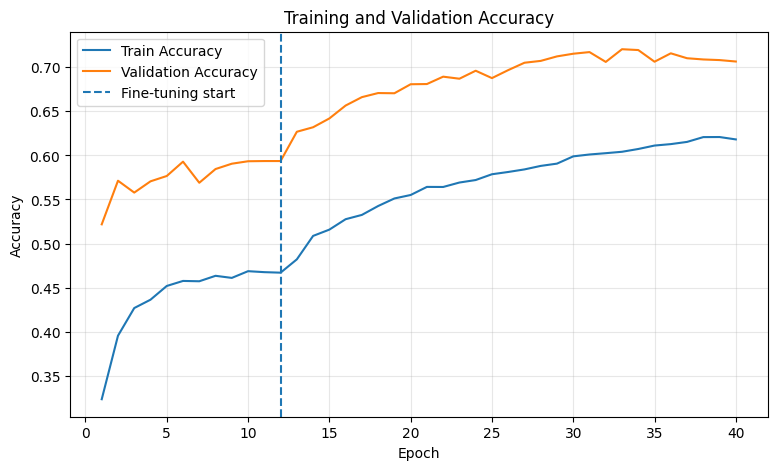

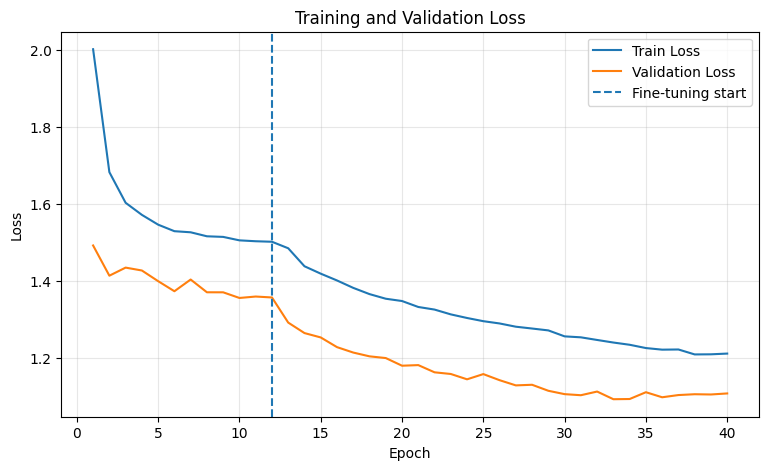

In [14]:
# 13) دمج Histories ورسم Accuracy وLoss

def merge_history(h1, h2):
    merged = {}
    keys = set(h1.history.keys()) | set(h2.history.keys())
    for key in keys:
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return merged

history = merge_history(history_stage1, history_stage2)
epochs_range = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, history["accuracy"], label="Train Accuracy")
plt.plot(epochs_range, history["val_accuracy"], label="Validation Accuracy")
plt.axvline(initial_epoch, linestyle="--", label="Fine-tuning start")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, history["loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.axvline(initial_epoch, linestyle="--", label="Fine-tuning start")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 198ms/step
Final Test Accuracy: 0.6029534689328504

Classification Report:

              precision    recall  f1-score   support

       angry     0.4952    0.4843    0.4897       958
     disgust     0.5429    0.5135    0.5278       111
        fear     0.4708    0.3066    0.3714      1024
       happy     0.8104    0.8382    0.8241      1774
     neutral     0.5261    0.6537    0.5830      1233
         sad     0.4697    0.4723    0.4710      1247
    surprise     0.7205    0.7353    0.7278       831

    accuracy                         0.6030      7178
   macro avg     0.5765    0.5720    0.5707      7178
weighted avg     0.5973    0.6030    0.5964      7178



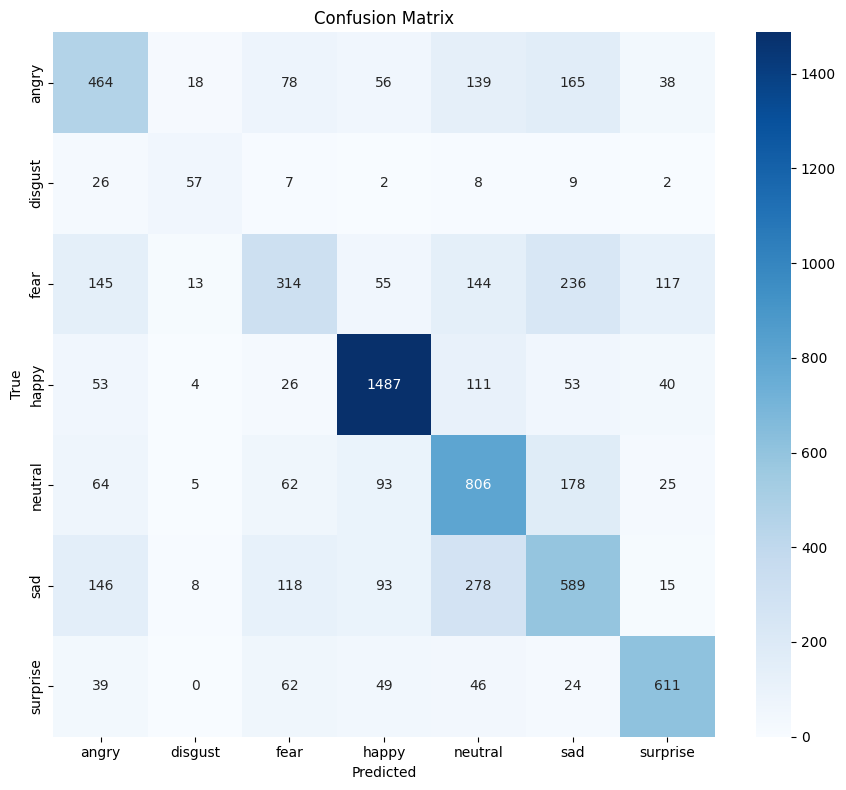

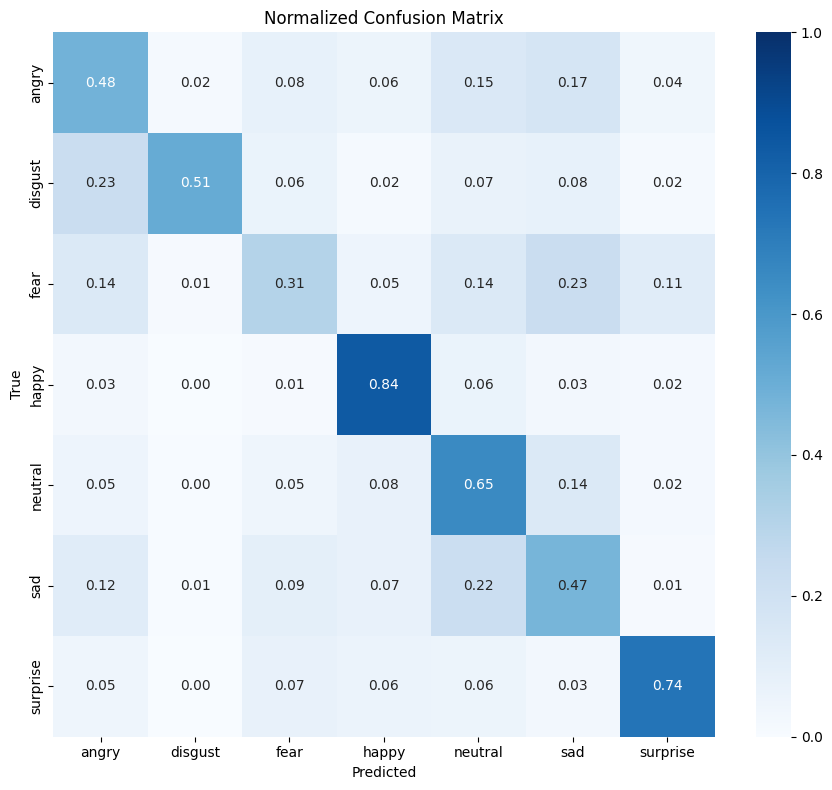

In [15]:
# 14) Classification Report و Confusion Matrix

y_true_onehot = np.concatenate(
    [labels.numpy() for _, labels in test_ds],
    axis=0
)
y_true = np.argmax(y_true_onehot, axis=1)

y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("Final Test Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
# 15) TTA اختياري لقياس الدقة فقط
# يأخذ متوسط توقع الصورة الأصلية وصورتها المعكوسة أفقياً.
# قد يرفع الدقة قليلاً، لكنه ليس جزءاً من نموذج TFLite نفسه.

def predict_with_horizontal_tta(model, dataset):
    all_probs = []
    all_labels = []

    for images, labels in dataset:
        probs_original = model(images, training=False)
        probs_flipped = model(
            tf.image.flip_left_right(images),
            training=False
        )
        probs = (probs_original + probs_flipped) / 2.0

        all_probs.append(probs.numpy())
        all_labels.append(labels.numpy())

    return (
        np.concatenate(all_probs, axis=0),
        np.concatenate(all_labels, axis=0)
    )

tta_prob, tta_true_onehot = predict_with_horizontal_tta(
    best_model,
    test_ds
)
tta_pred = np.argmax(tta_prob, axis=1)
tta_true = np.argmax(tta_true_onehot, axis=1)

print("TTA Test Accuracy:", accuracy_score(tta_true, tta_pred))
print(
    classification_report(
        tta_true,
        tta_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

TTA Test Accuracy: 0.6040679855112845
              precision    recall  f1-score   support

       angry     0.4984    0.4843    0.4913       958
     disgust     0.5185    0.5045    0.5114       111
        fear     0.4668    0.2949    0.3615      1024
       happy     0.8078    0.8433    0.8252      1774
     neutral     0.5293    0.6586    0.5869      1233
         sad     0.4744    0.4755    0.4750      1247
    surprise     0.7161    0.7377    0.7267       831

    accuracy                         0.6041      7178
   macro avg     0.5730    0.5713    0.5683      7178
weighted avg     0.5970    0.6041    0.5964      7178



In [17]:
# 16) تحويل النموذج إلى TFLite Float16

TFLITE_PATH = "/content/drive/MyDrive/fer2013_mobilenetv3_float16.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print("Saved:", TFLITE_PATH)
print("Size MB:", os.path.getsize(TFLITE_PATH) / (1024 ** 2))

Saved artifact at '/tmp/tmpms25szyg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='image')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134886858718288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886858718672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886739902928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886858718096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886858717904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886739904080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886739904272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886739903504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886739903888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886739904848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134886739902544: Tens

In [18]:
# 17) اختبار ملف TFLite على صورة واحدة

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

for images, labels in test_ds.take(1):
    sample = images[0:1].numpy().astype(input_details[0]["dtype"])
    true_class = CLASS_NAMES[int(np.argmax(labels[0].numpy()))]

    interpreter.set_tensor(input_details[0]["index"], sample)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]["index"])[0]
    predicted_class = CLASS_NAMES[int(np.argmax(output))]

    print("True class     :", true_class)
    print("Predicted class:", predicted_class)
    print("Confidence     :", float(np.max(output)))

Input details: [{'name': 'serving_default_image:0', 'index': 0, 'shape': array([  1, 160, 160,   3], dtype=int32), 'shape_signature': array([ -1, 160, 160,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 389, 'shape': array([1, 7], dtype=int32), 'shape_signature': array([-1,  7], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


True class     : angry
Predicted class: angry
Confidence     : 0.5051069855690002


In [19]:
# 18) حفظ أسماء الفئات لاستخدامها في Flutter

LABELS_PATH = "/content/drive/MyDrive/fer2013_labels.txt"

with open(LABELS_PATH, "w", encoding="utf-8") as f:
    for class_name in CLASS_NAMES:
        f.write(class_name + "\n")

print("Saved:", LABELS_PATH)

Saved: /content/drive/MyDrive/fer2013_labels.txt


Model input shape: [  1 160 160   3]
Model input dtype: <class 'numpy.float32'>

اختر صورة من جهازك:


Saving PrivateTest_932822.jpg to PrivateTest_932822.jpg
Uploaded image: PrivateTest_932822.jpg


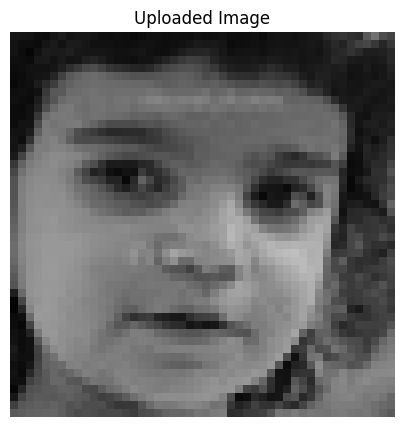

Prepared image shape: (1, 160, 160, 3)
Prepared image dtype: float32


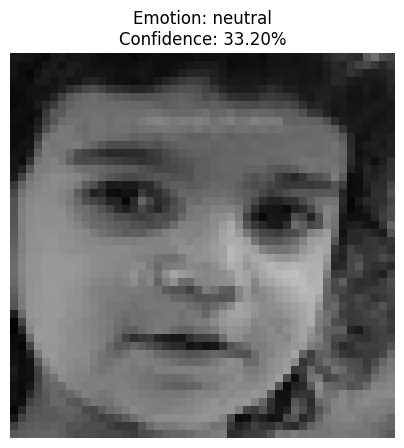

Predicted emotion: neutral
Confidence: 33.20%

All probabilities:
angry     :  15.26%
disgust   :   1.93%
fear      :  11.55%
happy     :   5.55%
neutral   :  33.20%
sad       :  25.10%
surprise  :   7.40%


In [24]:
# ==========================================
# رفع صورة حقيقية واختبارها باستخدام TFLite
# ==========================================

from google.colab import files
from PIL import Image
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ترتيب الفئات يجب أن يطابق ترتيب التدريب
CLASS_NAMES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

# مسار نموذج TFLite المحفوظ على Google Drive
TFLITE_PATH = "/content/drive/MyDrive/fer2013_mobilenetv3_float16.tflite"

# ------------------------------------------
# 1) تحميل نموذج TFLite
# ------------------------------------------

interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model input shape:", input_details[0]["shape"])
print("Model input dtype:", input_details[0]["dtype"])

# قراءة حجم الصورة المطلوب من النموذج تلقائياً
input_height = input_details[0]["shape"][1]
input_width = input_details[0]["shape"][2]

# ------------------------------------------
# 2) رفع الصورة من جهازك
# ------------------------------------------

print("\nاختر صورة من جهازك:")
uploaded = files.upload()

# الحصول على اسم أول صورة تم رفعها
image_name = next(iter(uploaded))

print("Uploaded image:", image_name)

# ------------------------------------------
# 3) قراءة وعرض الصورة
# ------------------------------------------

original_image = Image.open(image_name).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# ------------------------------------------
# 4) تجهيز الصورة لتناسب النموذج
# ------------------------------------------

resized_image = original_image.resize(
    (input_width, input_height),
    Image.Resampling.BILINEAR
)

input_image = np.array(resized_image, dtype=np.float32)

# إضافة Batch dimension
# من (160,160,3) إلى (1,160,160,3)
input_image = np.expand_dims(input_image, axis=0)

# لأن MobileNetV3 في الكود يحتوي include_preprocessing=True
# لا نستخدم input_image / 255.0

# تحويل نوع البيانات إلى النوع المطلوب من TFLite
input_image = input_image.astype(input_details[0]["dtype"])

print("Prepared image shape:", input_image.shape)
print("Prepared image dtype:", input_image.dtype)

# ------------------------------------------
# 5) تنفيذ التنبؤ
# ------------------------------------------

interpreter.set_tensor(
    input_details[0]["index"],
    input_image
)

interpreter.invoke()

prediction = interpreter.get_tensor(
    output_details[0]["index"]
)[0]

# ------------------------------------------
# 6) إظهار النتيجة
# ------------------------------------------

predicted_index = int(np.argmax(prediction))
predicted_emotion = CLASS_NAMES[predicted_index]
confidence = float(prediction[predicted_index]) * 100

plt.figure(figsize=(5, 5))
plt.imshow(original_image)
plt.title(
    f"Emotion: {predicted_emotion}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print("=" * 50)
print("Predicted emotion:", predicted_emotion)
print(f"Confidence: {confidence:.2f}%")
print("=" * 50)

print("\nAll probabilities:")

for emotion, probability in zip(CLASS_NAMES, prediction):
    print(f"{emotion:10s}: {float(probability) * 100:6.2f}%")